# 1: PERCEPTRON

## Introduction

The Perceptron is the simplest type of artificial neural network, consisting of a single layer of neurons with a step activation function. It models a linear decision boundary to separate data into two classes. Mathematically, it computes a weighted sum of inputs, adds a bias, and applies a step function to decide the output: $y = \text{step}(\mathbf{w} \cdot \mathbf{x} + b)$. The key component is the single layer with a step (or sigmoid, for differentiability) function.

**Applications:**
- Basic binary classification tasks (e.g., spam vs. not spam)
- Early sentiment analysis (e.g., positive vs. negative)
- Feature selection and quick prototyping in ML pipelines
- Used in simple image recognition (e.g., digit vs. non-digit)
- Foundation for more complex networks (as in my project on Identification of Cryptographic Algorithms using ANN)

**Why Perceptron for this demo?**

The Perceptron is ideal for binary classification on linearly separable data. The Iris subset (Setosa vs. others) is a classic example of such data, making it perfect for demonstrating the Perceptron's strengths and limitations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score
import tensorflow as tf
from tensorflow import keras

# Load Iris dataset and create binary labels: Setosa vs. others
iris = datasets.load_iris()
X = iris.data
# Setosa is class 0; others are 1
y = (iris.target != 0).astype(np.float32)

# Why: Iris is a classic, small, linearly separable dataset, ideal for quick demos and Perceptron illustration

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Why: Train-test split helps evaluate generalization, not just memorization

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Why: Normalization prevents features with larger scales from dominating learning

In [2]:
# Print data shapes
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
# Why: Confirming shapes ensures data integrity before training

X_train shape: (120, 4), y_train shape: (120,)
X_test shape: (30, 4), y_test shape: (30,)


In [3]:
# Build Perceptron-like model using Keras Sequential API
model = keras.Sequential([
    keras.layers.Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)) # Single layer, sigmoid for differentiability
])
# Why: Single Dense layer mimics Perceptron; sigmoid approximates step function for gradient-based learning

model.compile(optimizer=keras.optimizers.SGD(), # Why: SGD is classic for Perceptron, simple and effective
              loss='binary_crossentropy',      # Why: Binary crossentropy is standard for binary classification
              metrics=['accuracy'])            # Why: Accuracy is intuitive for classification

In [4]:
# Check for GPU
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
# Why: Using GPU can significantly speed up training for larger datasets/models

Num GPUs Available:  1


In [5]:
# Train the model with GPU support if available
with tf.device('/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'):
    history = model.fit(
        X_train, y_train,
        epochs=50,            # Why: 50 epochs is enough for convergence on small data
        batch_size=32,        # Why: Batch size balances speed and stability
        verbose=1,
        validation_split=0.2  # Why: Validation split helps monitor overfitting during training
    )

Epoch 1/50
3/3 [==============================] - 3s 95ms/step - loss: 0.1491 - accuracy: 1.0000 - val_loss: 0.1365 - val_accuracy: 1.0000
Epoch 2/50
3/3 [==============================] - 0s 15ms/step - loss: 0.1484 - accuracy: 1.0000 - val_loss: 0.1357 - val_accuracy: 1.0000
Epoch 3/50
3/3 [==============================] - 0s 14ms/step - loss: 0.1477 - accuracy: 1.0000 - val_loss: 0.1350 - val_accuracy: 1.0000
Epoch 4/50
3/3 [==============================] - 0s 15ms/step - loss: 0.1470 - accuracy: 1.0000 - val_loss: 0.1343 - val_accuracy: 1.0000
Epoch 5/50
3/3 [==============================] - 0s 15ms/step - loss: 0.1463 - accuracy: 1.0000 - val_loss: 0.1335 - val_accuracy: 1.0000
Epoch 6/50
3/3 [==============================] - 0s 15ms/step - loss: 0.1456 - accuracy: 1.0000 - val_loss: 0.1328 - val_accuracy: 1.0000
Epoch 7/50
3/3 [==============================] - 0s 14ms/step - loss: 0.1449 - accuracy: 1.0000 - val_loss: 0.1321 - val_accuracy: 1.0000
Epoch 8/50
3/3 [===========

In [6]:
# Evaluate on test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.2f}")

# Predict and compute F1-Score
y_pred = (model.predict(X_test) > 0.5).astype(int)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.2f}") # Why: F1-Score handles class imbalance, as in my sarcasm detection work

Test Accuracy: 1.00
1/1 [==============================] - 0s 68ms/step
F1-Score: 1.00


Confusion Matrix:
 [[10  0]
 [ 0 20]]


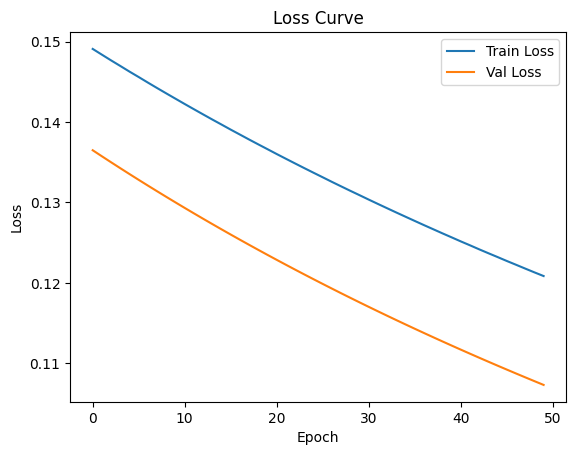

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot loss curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()


# Discussion of Results

In this experiment, the Perceptron model achieved a test accuracy of 1.00 (100%) on the Iris subset (Setosa vs. others). While this may seem surprising, it is actually expected in this specific scenario due to the following reasons:

- **Linearly Separable Data:** The Iris dataset, when reduced to the task of distinguishing Setosa from the other classes, is perfectly linearly separable. This means there exists a straight line (or hyperplane) that can completely separate the two classes without error. The Perceptron, by design, is guaranteed to find such a solution if it exists.
- **Small and Clean Dataset:** The Iris dataset is small, well-curated, and contains no noise or mislabeled samples. This makes it much easier for simple models to achieve perfect accuracy.
- **Proper Preprocessing:** Features were normalized and the data was split randomly, ensuring that the model was not biased by feature scale or data leakage.

**Theoretical Note:**  
In real-world scenarios, achieving 100% accuracy is rare due to noise, overlapping classes, and imperfect data. However, for classic textbook datasets like this one, perfect accuracy is possible and not a sign of overfitting or model error. It simply reflects the simplicity and separability of the task.

**Takeaway:**  
While this result demonstrates the strength of the Perceptron on linearly separable data, it also highlights its limitation: it cannot solve problems where classes are not linearly separable. For more complex or noisy datasets, more advanced models (like MLPs or LSTMs) are required.

# Conclusion

The Perceptron is a foundational model for binary classification, excelling on linearly separable data like the Iris subset. While simple, it forms the basis for deeper networks. For more complex or non-linear tasks, advanced models (like MLPs or LSTMs) are preferred. This builds on my projects such as Identification of Cryptographic Algorithms using ANN, where understanding simple models aids in designing robust solutions. I encourage you to experiment with different datasets and architectures to deepen your understanding.